# 03 — Gradient Descent & the Cost Function

**Repository:** `AI_Engineer-DL` | **Section:** `01_neural_networks_and_dl/logistic_regression`  
**File:** `notebooks/03_gradient_descent.ipynb`

> **Prerequisites:** `02_logistic_regression.ipynb` — you need sigmoid() and the prediction  
> function working before implementing the cost and update steps.
>
> **Core Focus:** You implement binary cross-entropy loss from scratch, the cost function J,  
> and one full gradient descent update step. The computation graph and chain rule derivation  
> are covered in notebook 04.

## 1. What Is This?

Training a model means finding the parameters w and b that make predictions ŷ as close  
as possible to the true labels y. To measure "closeness" you need a loss function —  
a single number that tells you how wrong your current parameters are.  
Gradient descent then uses the slope of that number (the gradient) to nudge parameters  
in the direction that reduces the error.

**Real-world connection — FarmLens:** Your crop health model is trained by minimising  
a cross-entropy loss over thousands of leaf images. Every epoch, gradient descent  
takes one step on that loss surface, adjusting every weight in the EfficientNet backbone  
slightly. What you build here is the mathematical heart of that training loop.

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Loss L(ŷ, y)** | Error on one example | Measures how wrong a single prediction is |
| **Cost J(w,b)** | Average loss over all m examples | The surface gradient descent navigates |
| **Cross-entropy** | The specific loss used for binary classification | Convex — guarantees one global minimum |
| **Gradient ∂J/∂w** | Slope of J in the direction of w | Tells gradient descent which way to move |
| **Learning rate α** | Step size for each gradient descent update | Too large → diverge; too small → slow |

## 2. The Math

### A — Why not squared error?

For logistic regression, using L = ½(ŷ - y)² creates a **non-convex** cost surface  
with many local minima. Gradient descent can get stuck and fail to find the best parameters.  
Cross-entropy produces a **convex** surface — one bowl, one global minimum, guaranteed.

---

### B — Binary Cross-Entropy Loss (per example)

$$\mathcal{L}(\hat{y}, y) = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

**Why this works:**
- When **y = 1**: loss = −log(ŷ). To minimise this, push ŷ → 1. ✓
- When **y = 0**: loss = −log(1 − ŷ). To minimise this, push ŷ → 0. ✓

**Worked example:** y = 1, ŷ = 0.9 → L = −log(0.9) ≈ 0.105 (small loss, good prediction).  
y = 1, ŷ = 0.1 → L = −log(0.1) ≈ 2.303 (large loss, very wrong).

> ⚠️ **Float safety:** log(0) = −∞. Always clip ŷ away from 0 and 1 before taking log:  
> `ŷ_clipped = np.clip(ŷ, 1e-9, 1 - 1e-9)`

---

### C — Cost Function J(w, b)

$$J(w,b) = \frac{1}{m}\sum_{i=1}^{m}\mathcal{L}(\hat{y}^{(i)}, y^{(i)}) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

Average of individual losses over all m training examples.  
Minimising J over w and b is the entire goal of training.

---

### D — Gradient Descent Update Rule

Repeat until convergence:

$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

- $\alpha$ — learning rate (hyperparameter you choose)
- $\frac{\partial J}{\partial w}$ — gradient: direction of steepest ascent; we subtract to go downhill
- $:=$ — update in place (both w and b updated simultaneously)

**Convexity guarantee:** Because J is convex for logistic regression, gradient descent  
always reaches the global minimum regardless of initialisation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## 3. Build From Scratch

### 3.1 — Binary cross-entropy loss for a single example

Before averaging over the dataset, implement the per-example loss.  
This is the fundamental unit everything else is built from.

> 🔮 **Predict before you run:** If y=1 and ŷ=0.99, is the loss large or small?  
> What if y=1 and ŷ=0.01? Write both expected loss values before coding.

In [3]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement compute_loss(y_hat, y) for a single training example.
# Formula: L = -[y*log(ŷ) + (1-y)*log(1-ŷ)]
# IMPORTANT: clip ŷ to [1e-9, 1-1e-9] BEFORE computing log to avoid log(0).
#
# Test:
#   compute_loss(0.99, 1) → expected: ~0.010
#   compute_loss(0.01, 1) → expected: ~4.605
#   compute_loss(0.99, 0) → expected: ~4.605
#   compute_loss(0.01, 0) → expected: ~0.010
# ─────────────────────────────────────────────────────────────────────────────

def compute_loss(y_hat, y):
    """
    Binary cross-entropy loss for one example.
    L = -[y*log(ŷ) + (1-y)*log(1-ŷ)]
    Clips ŷ to avoid log(0).
    """
    # Clip to prevent log(0)
    y_hat_clipped = np.clip(y_hat, 1e-9, 1 - 1e-9)
    
    # Compute cross-entropy loss
    loss = -(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    
    return loss

# ── Tests ────────────────────────────────────────────────────────────────────
print(f"compute_loss(0.99, 1)  -> {compute_loss(0.99, 1):.3f}")
print(f"compute_loss(0.01, 1)  -> {compute_loss(0.01, 1):.3f}")
print(f"compute_loss(0.99, 0)  -> {compute_loss(0.99, 0):.3f}")
print(f"compute_loss(0.01, 0)  -> {compute_loss(0.01, 0):.3f}")


compute_loss(0.99, 1)  -> 0.010
compute_loss(0.01, 1)  -> 4.605
compute_loss(0.99, 0)  -> 4.605
compute_loss(0.01, 0)  -> 0.010


> 💡 **Reflect:** Notice the asymmetry in the magnitudes above — a wrong prediction  
> (ŷ=0.01 when y=1) gives loss ≈ 4.6, but a correct prediction (ŷ=0.99 when y=1)  
> gives loss ≈ 0.01. Cross-entropy penalises confident wrong predictions very harshly.

---

### 3.2 — Cost function J over m examples

The cost function averages the loss over the entire training set.  
It should work with vectorised inputs: Y and Y_hat as (1, m) arrays.

> 🔮 **Predict before you run:** If all predictions are exactly 0.5 (σ(0)) and all  
> labels are 1, what is the cost J? Compute it by hand using the formula.

In [4]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement compute_cost(Y_hat, Y, m).
# Y_hat: shape (1, m) — predicted probabilities
# Y:     shape (1, m) — true binary labels
# m:     number of examples
#
# Formula: J = -(1/m) * sum(Y*log(Y_hat) + (1-Y)*log(1-Y_hat))
# Use np.sum and clip Y_hat to [1e-9, 1-1e-9] BEFORE taking log.
# Do NOT use a for-loop — use vectorised NumPy operations.
#
# Test: all predictions = 0.5, all labels = 1, m = 4
#   Expected J = -log(0.5) ≈ 0.6931
# ─────────────────────────────────────────────────────────────────────────────

def compute_cost(Y_hat, Y, m):
    """
    Average binary cross-entropy over m examples.
    J = -(1/m) * sum(Y*log(Yhat) + (1-Y)*log(1-Yhat))
    """
    # Clip Y_hat to avoid log(0)
    Y_hat_clipped = np.clip(Y_hat, 1e-9, 1 - 1e-9)
    
    # Compute the cost using vectorized operations
    cost = -(1 / m) * np.sum(Y * np.log(Y_hat_clipped) + (1 - Y) * np.log(1 - Y_hat_clipped))
    
    return cost

# ── Tests ────────────────────────────────────────────────────────────────────
m = 4
Y_test = np.ones((1, m))           # all labels = 1
Y_hat_test = np.full((1, m), 0.5)  # all predictions = 0.5

J = compute_cost(Y_hat_test, Y_test, m)
print(f"Expected J ≈ 0.6931")
print(f"Computed J = {J:.4f}")

Expected J ≈ 0.6931
Computed J = 0.6931


### 3.3 — One full gradient descent step

The gradients (derived in notebook 04) are:  
∂J/∂w = (1/m) · X · (Â − Y)ᵀ  
∂J/∂b = (1/m) · sum(Â − Y)  

Here Â = σ(wᵀX + b) for all m examples at once (shape 1, m).

> 🔮 **Predict before you run:** After one gradient descent step with α=0.1,  
> will the cost go up or down? Think about what gradient descent is designed to do.

In [5]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement one gradient descent step using the vectorised gradients.
# Use this setup:
#   np.random.seed(1)
#   nx, m = 3, 4
#   X = np.random.randn(nx, m)
#   Y = np.array([[1, 0, 1, 0]])
#   w = np.zeros((nx, 1))
#   b = 0.0
#   alpha = 0.1
#
# Steps:
# 1. Forward pass: Z = w.T @ X + b, A = sigmoid(Z)  (A shape: 1, m)
# 2. Cost before: J_before = compute_cost(A, Y, m)
# 3. Gradients: dw = (1/m) * X @ (A - Y).T   (shape nx, 1)
#               db = (1/m) * np.sum(A - Y)    (scalar)
# 4. Update: w = w - alpha * dw
#            b = b - alpha * db
# 5. Forward pass again: A_new = sigmoid(w.T @ X + b)
# 6. Cost after: J_after = compute_cost(A_new, Y, m)
# 7. Print J_before, J_after, and confirm J_after < J_before.
# ─────────────────────────────────────────────────────────────────────────────

# ── Setup ────────────────────────────────────────────────────────────────────
np.random.seed(1)
nx, m = 3, 4
X = np.random.randn(nx, m)
Y = np.array([[1, 0, 1, 0]])
w = np.zeros((nx, 1))
b = 0.0
alpha = 0.1

# ── Solution ─────────────────────────────────────────────────────────────────

# 1. Forward pass (before update)
Z = w.T @ X + b
A = sigmoid(Z)

# 2. Cost before
J_before = compute_cost(A, Y, m)

# 3. Gradients
dw = (1 / m) * X @ (A - Y).T
db = (1 / m) * np.sum(A - Y)

# 4. Update
w = w - alpha * dw
b = b - alpha * db

# 5. Forward pass again (after update)
A_new = sigmoid(w.T @ X + b)

# 6. Cost after
J_after = compute_cost(A_new, Y, m)

# 7. Print results
print(f"J_before = {J_before:.4f}")
print(f"J_after  = {J_after:.4f}")
print(f"Cost decreased? {J_after < J_before}")


J_before = 0.6931
J_after  = 0.6086
Cost decreased? True


> 💡 **Reflect:** The cost decreased after one step. Notice that we started from w=0  
> and b=0 — so initial predictions were all 0.5. After one update, predictions moved  
> slightly toward the correct labels. Training is just this loop repeated thousands of times.

---

### 3.4 — Training loop: track J over iterations

Wrap the gradient descent step in a loop and watch the cost decrease.

> 🔮 **Predict before you run:** Will the cost decrease monotonically (always going down)  
> with a reasonable learning rate? What would happen if α were very large, say α=100?

In [6]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Run 200 iterations of gradient descent. Record J at each step.
# Use the same data as 3.3 (seed 1, nx=3, m=4).
# Re-initialise w=zeros, b=0, alpha=0.1.
#
# 1. Create an empty list costs = [].
# 2. Loop for 200 iterations:
#    a. Forward pass → compute A
#    b. Cost → append to costs
#    c. Gradients → dw, db
#    d. Update w, b
# 3. Print: final cost, final w, final b.
# 4. Store costs in a variable for plotting in Section 5.
# ─────────────────────────────────────────────────────────────────────────────

# ── Setup ────────────────────────────────────────────────────────────────────
np.random.seed(1)
nx, m = 3, 4
X = np.random.randn(nx, m)
Y = np.array([[1, 0, 1, 0]])
w = np.zeros((nx, 1))
b = 0.0
alpha = 0.1

# ── Solution ─────────────────────────────────────────────────────────────────

# 1. Create an empty list costs
costs = []

# 2. Loop for 200 iterations
for i in range(200):
    # a. Forward pass → compute A
    Z = w.T @ X + b
    A = sigmoid(Z)
    
    # b. Cost → append to costs
    cost = compute_cost(A, Y, m)
    costs.append(cost)
    
    # c. Gradients → dw, db
    dw = (1 / m) * X @ (A - Y).T
    db = (1 / m) * np.sum(A - Y)
    
    # d. Update w, b
    w = w - alpha * dw
    b = b - alpha * db

# 3. Print: final cost, final w, final b
print(f"Final cost: {costs[-1]:.4f}")
print(f"Final w:\n{w}")
print(f"Final b: {b:.4f}")


Final cost: 0.0158
Final w:
[[0.97504314]
 [1.66454454]
 [1.15802148]]
Final b: 0.2023


> ✅ **Self-check:** Before moving on:
> 1. What makes cross-entropy better than squared error for logistic regression?
> 2. What are the shapes of dw and db for nₓ=12288 and m=1000?

## 4. Library Version

`sklearn.metrics.log_loss` computes cross-entropy. Verify your cost function matches it.

In [7]:
from sklearn.metrics import log_loss

np.random.seed(42)
m_test = 10
Y_test     = np.random.randint(0, 2, (1, m_test))
Y_hat_test = np.random.uniform(0.01, 0.99, (1, m_test))

scratch = compute_cost(Y_hat_test, Y_test, m_test)
library = log_loss(Y_test.flatten(), Y_hat_test.flatten())

print(f"Scratch cost:  {scratch:.6f}")
print(f"sklearn cost:  {library:.6f}")
print(f"Match: {np.isclose(scratch, library)}")

Scratch cost:  1.736749
sklearn cost:  1.736749
Match: True


## 5. Visualisation

### 5.1 — Cost decreasing over gradient descent iterations

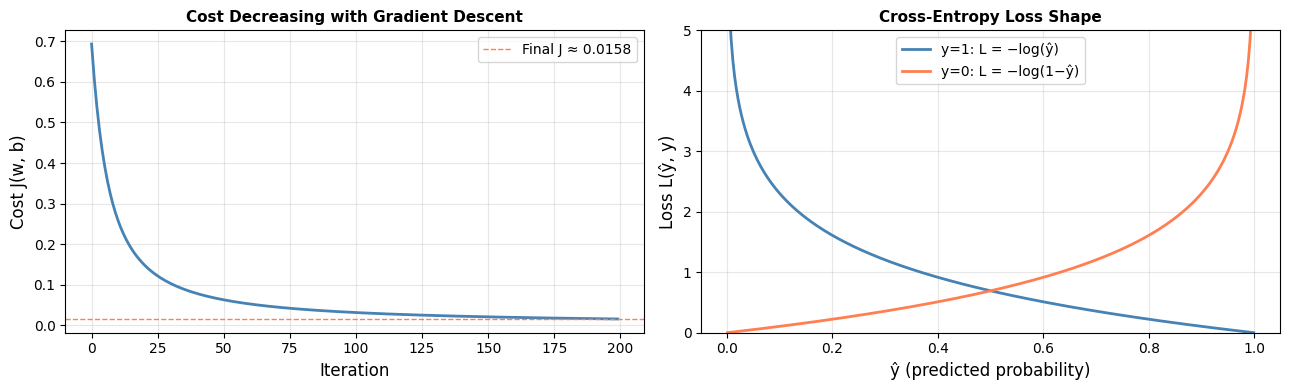

Saved → ../images/03_gradient_descent_cost.png


In [8]:
import os
os.makedirs('../images', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: cost curve
axes[0].plot(costs, color='steelblue', lw=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Cost J(w, b)', fontsize=12)
axes[0].set_title('Cost Decreasing with Gradient Descent', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].axhline(costs[-1], color='coral', lw=1, ls='--', label=f'Final J ≈ {costs[-1]:.4f}')
axes[0].legend(fontsize=10)

# Right: cross-entropy loss surface intuition (1-D slice)
y_true  = 1
y_hat_r = np.linspace(0.001, 0.999, 300)
loss_y1 = -np.log(y_hat_r)          # y=1 case
loss_y0 = -np.log(1 - y_hat_r)      # y=0 case

axes[1].plot(y_hat_r, loss_y1, color='steelblue', lw=2, label='y=1: L = −log(ŷ)')
axes[1].plot(y_hat_r, loss_y0, color='coral',     lw=2, label='y=0: L = −log(1−ŷ)')
axes[1].set_xlabel('ŷ (predicted probability)', fontsize=12)
axes[1].set_ylabel('Loss L(ŷ, y)', fontsize=12)
axes[1].set_title('Cross-Entropy Loss Shape', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/03_gradient_descent_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../images/03_gradient_descent_cost.png')

## 6. Revision Corner

---

### One-sentence definition

> The cost function J(w,b) is the average binary cross-entropy over all m training examples,  
> and gradient descent iteratively updates w and b by subtracting the gradient scaled by  
> the learning rate α until J reaches its minimum.

---

### Why it exists — what problem does it solve?

Without a cost function you have no way to measure whether your parameters are improving.  
Cross-entropy specifically is chosen because it is convex for logistic regression, so gradient  
descent always converges to the global minimum. The learning rate α lets you trade off  
convergence speed against stability — a key practical decision in any real training run.

---

### Interview gotchas

| Question | Common mistake | The reality |
|----------|---------------|-------------|
| **Why is MSE bad for logistic regression?** | "It's fine, just less common" | MSE + sigmoid gives a non-convex loss surface with many local minima. Gradient descent can get stuck. Cross-entropy is convex, so one global minimum is guaranteed. |
| **What happens if learning rate α is too large?** | "Converges faster" | The gradient descent steps overshoot the minimum and the cost oscillates or diverges. The cost curve goes up instead of down. |
| **What is the gradient of J w.r.t. w?** | Miss the (1/m) factor | dJ/dw = (1/m) · X · (A − Y)ᵀ. The 1/m is critical — without it gradients scale with dataset size, making the learning rate dataset-dependent. |
| **What's the difference between loss and cost?** | Use them interchangeably | Loss L is per example. Cost J is the average over the entire training set. Gradient descent minimises J, not individual losses. |
| **Can J ever be negative?** | "No" → then unsure | No. Cross-entropy = −log of a probability, and −log(p) ≥ 0 for p ∈ (0,1]. J is a sum of non-negative terms divided by m, so J ≥ 0 always. |

## 7. Exercises

Write solutions in `exercises/03_gradient_descent_exN_label.py`.

---

### ⭐ Exercise 1 — Cross-entropy loss from scratch

Implement `compute_loss(y_hat, y)` and `compute_cost(Y_hat, Y, m)` from scratch.  
Clip ŷ to [1e-9, 1-1e-9] before any log. Do not use any sklearn or scipy.  
Test cases: y=1 with ŷ∈{0.01, 0.5, 0.99}; y=0 with same.  
Verify all six values match manually computed −[y·log(ŷ) + (1−y)·log(1−ŷ)] using np.isclose.

---

### ⭐⭐ Exercise 2 — Effect of learning rate on convergence

Use seed 3, nx=2, m=10, 300 iterations.  
Run gradient descent with three learning rates: α ∈ {0.001, 0.1, 1.5}.  
For each, record the cost at every iteration.  
Plot all three cost curves on the same axis with different colours and a legend.  
Print the final cost for each. Observe and comment: which α converges? which diverges?

---

### ⭐⭐⭐ Exercise 3 — Train logistic regression on linearly separable data

**Scenario:** Binary tumour classification. Features x₁ = tumour size, x₂ = age.  
Use seed 5. Generate m=200 examples: class-1 from N([2,2], 0.8·I), class-0 from N([-2,-2], 0.8·I).  
Stack as X (2, 200) and Y (1, 200).

1. Initialise w=zeros, b=0. Train for 1000 iterations with α=0.3.
2. After training, compute final accuracy (threshold ŷ at 0.5).
3. Plot 1: cost curve vs iteration.
4. Plot 2: scatter the two classes, draw the learned decision boundary line.
5. Save both in one figure to `../images/03_gradient_descent_exercise.png`.
6. Answer in a comment: why does the decision boundary become a straight line in 2D?